In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 0. EDA

In [2]:
# Load train information dataset
train_df = pd.read_csv("/kaggle/input/happy-whale-and-dolphin/train.csv")
train_df 

,image,species,individual_id
0,00021adfb725ed.jpg,melon_headed_whale,cadddb1636b9
1,000562241d384d.jpg,humpback_whale,1a71fbb72250
2,0007c33415ce37.jpg,false_killer_whale,60008f293a2b
3,0007d9bca26a99.jpg,bottlenose_dolphin,4b00fe572063
4,00087baf5cef7a.jpg,humpback_whale,8e5253662392
...,...,...,...
51028,fff639a7a78b3f.jpg,beluga,5ac053677ed1
51029,fff8b32daff17e.jpg,cuviers_beaked_whale,1184686361b3
51030,fff94675cc1aef.jpg,blue_whale,5401612696b9
51031,fffbc5dd642d8c.jpg,beluga,4000b3d7c24e


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51033 entries, 0 to 51032
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   image          51033 non-null  object
 1   species        51033 non-null  object
 2   individual_id  51033 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [4]:
train_df.describe()

,image,species,individual_id
count,51033,51033,51033
unique,51033,30,15587
top,00021adfb725ed.jpg,bottlenose_dolphin,37c7aba965a5
freq,1,9664,400


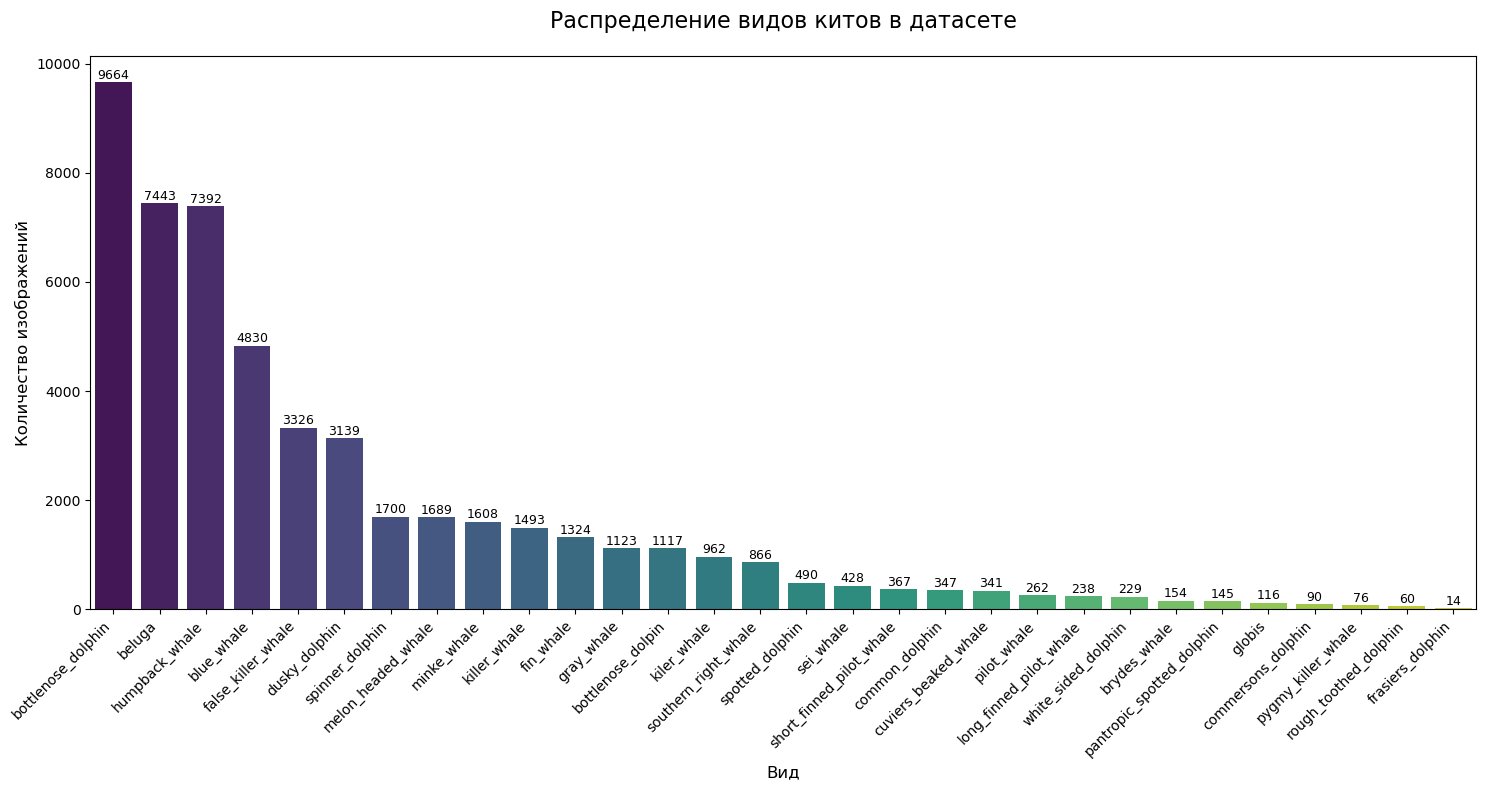

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Предположим, ваш датасет загружен в переменную df
df = train_df

# Создаем фигуру
plt.figure(figsize=(15, 8))

# Сортируем виды по количеству изображений
species_counts = df['species'].value_counts().sort_values(ascending=False)

# Строим barplot
ax = sns.barplot(
    x=species_counts.index, 
    y=species_counts.values,
    palette="viridis"
)

# Настройки графика
plt.title("Распределение видов китов в датасете", fontsize=16, pad=20)
plt.xlabel("Вид", fontsize=12)
plt.ylabel("Количество изображений", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворот подписей

# Добавляем подписи значений
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='center', 
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Список классов для класса 0 (с корректировкой опечаток)
negative_classes = ['blue_whale', 'false_killer_whale', 'dusky_dolphin',
    'spinner_dolphin', 'melon_headed_whale', 'minke_whale', 'killer_whale',
    'gray_whale', 'southern_right_whale', 'spotted_dolphin', 'sei_whale',
    'short_finned_pilot_whale', 'common_dolphin', 'cuviers_beaked_whale',
    'pilot_whale', 'long_finned_pilot_whale', 'white_sided_dolphin',
    'brydes_whale', 'pantropic_spotted_dolphin', 'commersons_dolphin',
    'pygmy_killer_whale', 'rough_toothed_dolphin', 'frasiers_dolphin'
]

# Фильтрация данных
humpback_df = df[df['species'] == 'humpback_whale']
negative_df = df[df['species'].isin(negative_classes)]

# Балансировка: берем все negative классы и столько же humpback
# n_samples = min(len(humpback_df), len(negative_df))
n_samples = 6000
balanced_df = pd.concat([
    humpback_df.sample(n_samples, random_state=42),
    negative_df.sample(n_samples, random_state=42)
])

# Создание бинарных меток
balanced_df['label'] = balanced_df['species'].apply(
    lambda x: 1 if x == 'humpback_whale' else 0
)

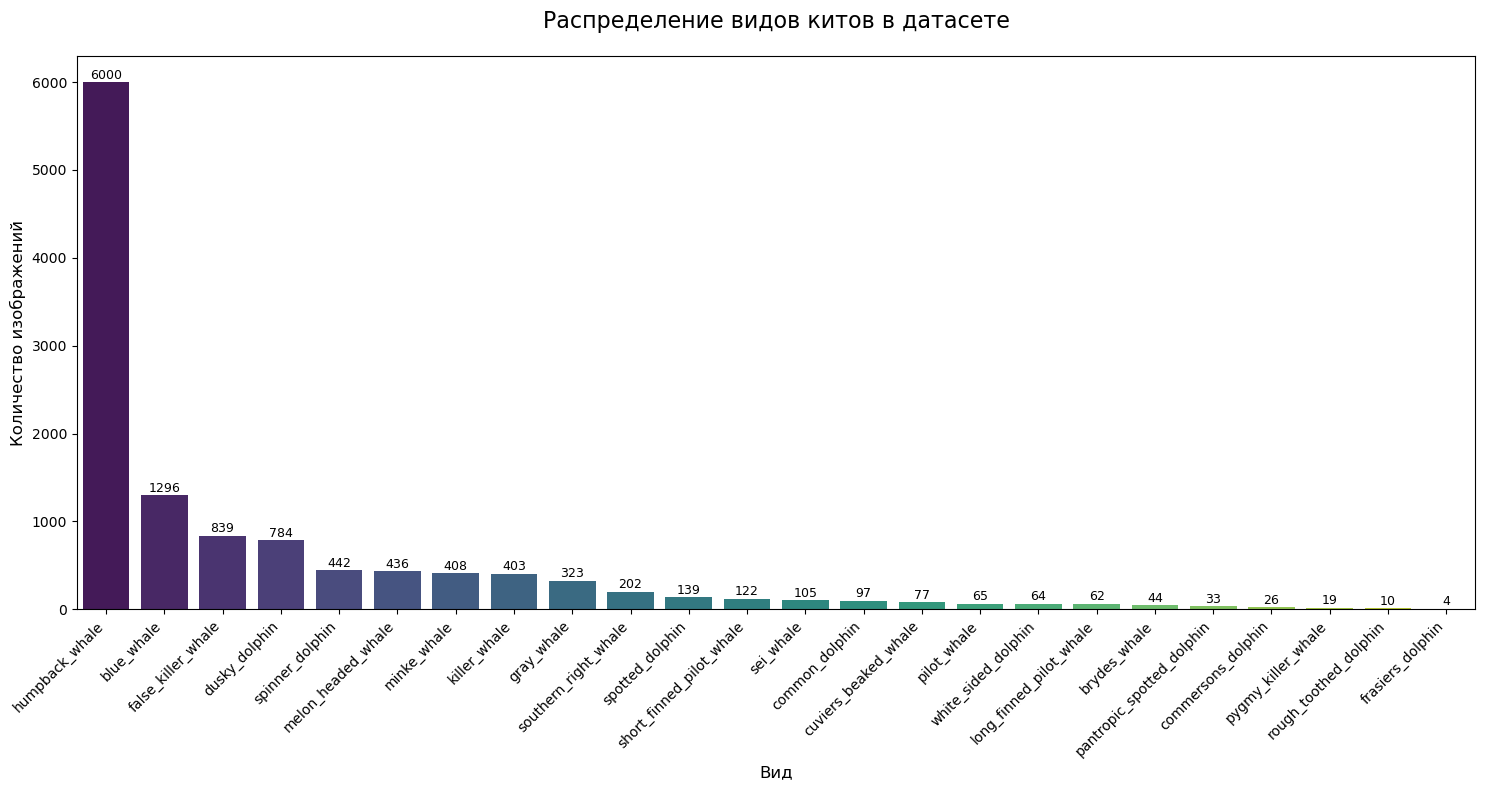

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Создаем фигуру
plt.figure(figsize=(15, 8))

# Сортируем виды по количеству изображений
species_counts = balanced_df['species'].value_counts().sort_values(ascending=False)

# Строим barplot
ax = sns.barplot(
    x=species_counts.index, 
    y=species_counts.values,
    palette="viridis"
)

# Настройки графика
plt.title("Распределение видов китов в датасете", fontsize=16, pad=20)
plt.xlabel("Вид", fontsize=12)
plt.ylabel("Количество изображений", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворот подписей

# Добавляем подписи значений
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='center', 
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [8]:
balanced_df.tail(100)

,image,species,individual_id,label
27823,8c42f5448c6e8b.jpg,false_killer_whale,ce873781a2c4,0
26322,84fa2cb56527fc.jpg,southern_right_whale,05b9243249fd,0
9928,31ee471a7da7c9.jpg,spinner_dolphin,dd86840723ee,0
13105,41ecc97c6f45da.jpg,blue_whale,23f239de0f5b,0
32590,a3e59f6b0bd6eb.jpg,false_killer_whale,7355eee87d75,0
...,...,...,...,...
18203,5bb9170fff163a.jpg,dusky_dolphin,f5ce5be40b0d,0
20342,669da60064e285.jpg,long_finned_pilot_whale,10b2ad514bae,0
21207,6b0b7a6192ad2d.jpg,false_killer_whale,366200ff5b49,0
14523,493080c839a7a3.jpg,short_finned_pilot_whale,3d65241c200f,0


In [9]:
train_df, val_df = train_test_split(
    balanced_df, 
    test_size=0.2, 
    stratify=balanced_df['label'],
    random_state=42
)

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
from tqdm import tqdm

import cv2

class WhaleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open('/kaggle/input/happy-whale-and-dolphin/train_images/' + row['image']).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(row['label'])

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Даталоадеры
train_dataset = WhaleDataset(train_df, train_transform)
val_dataset = WhaleDataset(val_df, val_transform)

train_loader = DataLoader(train_dataset,
    batch_size=64,  # Увеличить насколько позволяет память GPU
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,  # Можно больше чем для train
)

# Модель
model = models.efficientnet_b4(pretrained=True)


model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to('cuda')

# Оптимизатор и лосс
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import numpy as np

# Цикл обучения
best_acc = 0
for epoch in tqdm(range(15)):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
    # Валидация
    model.eval()
    val_loss = 0
    correct = 0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()
            
            preds = outputs.argmax(dim=1)
            probs = torch.softmax(outputs, dim=1)[:, 1] # Probability for the positive class (assuming class 1)

            correct += (preds == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    val_loss /= len(val_loader)
    acc = correct / len(val_dataset)
    
    # Calculate metrics
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    # Handle cases where ROC AUC might be undefined (e.g., only one class present in labels)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = 0.5 # Or np.nan, or skip printing

    if acc > best_acc:
        best_acc = acc
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        if epoch - best_epoch > 5:
            print("Early stopping")
            break
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}: Val Loss {val_loss:.4f}, Acc {acc:.4f}, Precision {precision:.4f}, Recall {recall:.4f}, F1 {f1:.4f}, ROC AUC {roc_auc:.4f}")

/opt/conda/lib/python3.7/site-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and may be removed in the future, "
/opt/conda/lib/python3.7/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-7eb33cd5.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-7eb33cd5.pth


  0%|          | 0.00/74.5M [00:00<?, ?B/s]

  7%|▋         | 1/15 [25:48<6:01:19, 1548.56s/it]

Epoch 1: Val Loss 0.2233, Acc 0.9083, Precision 0.8864, Recall 0.9367, F1 0.9109, ROC AUC 0.9734


 13%|█▎        | 2/15 [49:34<5:19:52, 1476.37s/it]

Epoch 2: Val Loss 0.1279, Acc 0.9475, Precision 0.9416, Recall 0.9542, F1 0.9478, ROC AUC 0.9905
